# Train FQF

FQF learns where to place its quantile fractions as well as the return values at those fractions. This notebook trains it on `CartPole-v1` and plots its learning curve.

## Defining idea

The fraction proposal network produces interval probabilities $q_i$. Their cumulative sums define boundaries $\tau_i$, and each quantile value is evaluated at an interval midpoint $\hat\tau_i$:

$$\tau_0=0,\qquad \tau_i=\sum_{j=0}^{i-1}q_j,\qquad \hat\tau_i=\frac{\tau_i+\tau_{i+1}}{2}.$$

The expected action value is the probability-weighted sum

$$Q(s,a)=\sum_i(\tau_{i+1}-\tau_i)Z_{\hat\tau_i}(s,a).$$

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import FQF, FQFConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "CartPole-v1"

In [2]:
env = gym.make(ENV_ID)
config = FQFConfig(
    quantiles=32,
    buffer_size=10_000,
    batch_size=64,
    learning_starts=500,
    target_update_interval=250,
    exploration_steps=2_000,
    seed=7,
)

agent = FQF(env, config=config, device="cpu")
agent.learn(total_timesteps=10_000, progress_bar=False)
env.close()

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

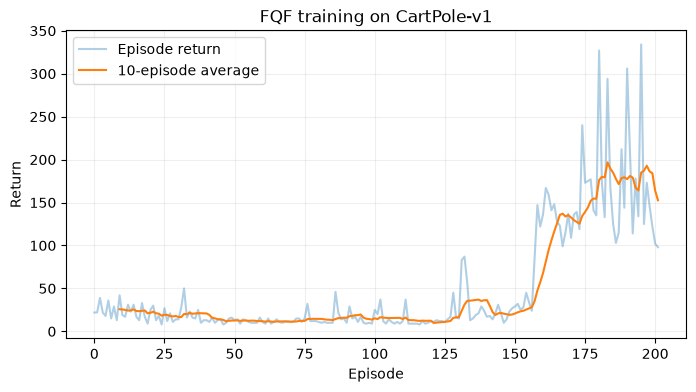

In [3]:
returns = np.asarray(agent.episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"FQF training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs 5 episodes using deterministic actions.

In [4]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(
        agent, evaluation_env, episodes=5, deterministic=True, seed=1_000
    )
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (152.0, 192.0, 148.0, 254.0, 140.0)
Mean return: 177.2 +/- 42.4
